In [ ]:
import os
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt

# === 1. Indstil parametre ===
mappe_path = "/Users/alhu/Data/Performance"          # <-- SKIFT denne til din mappe
benchmark_fil = "/Users/alhu/Data/Performance/qwen3_127A.xlsx"

/Users/alhu/miniconda3/envs/work/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


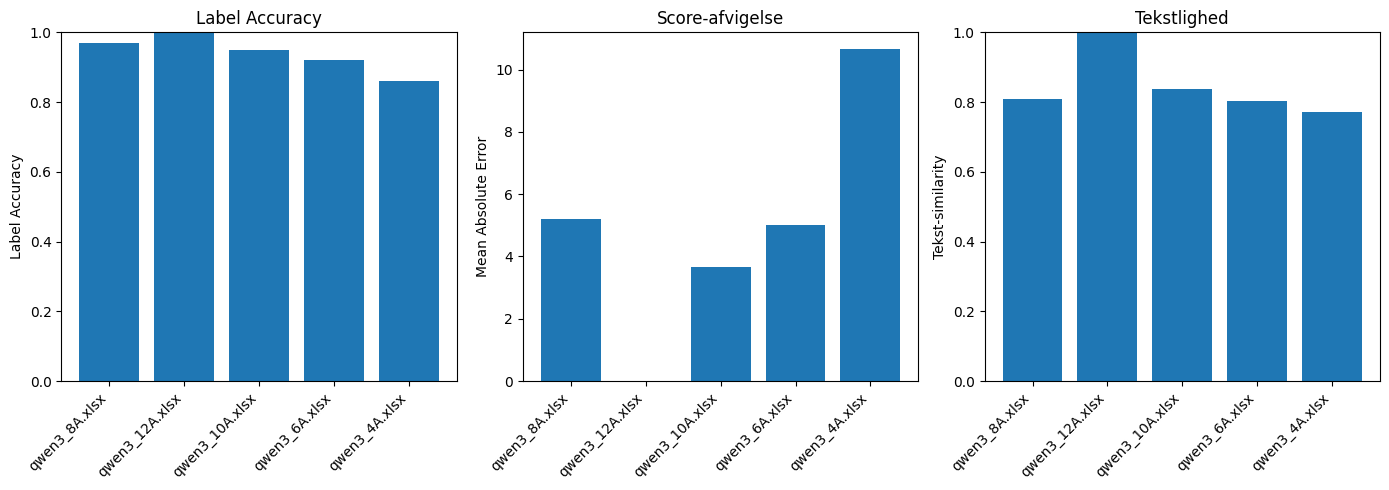

,fil,label_accuracy,score_mae,text_similarity
0,qwen3_8A.xlsx,0.97,5.20,0.809010
1,qwen3_12A.xlsx,1.00,0.00,1.000000
2,qwen3_10A.xlsx,0.95,3.65,0.836607
3,qwen3_6A.xlsx,0.92,5.00,0.803588
4,qwen3_4A.xlsx,0.86,10.66,0.772308


In [2]:
benchmark_path = os.path.join(mappe_path, benchmark_fil)

# === 2. Indlæs benchmark-data ===
benchmark_df = pd.read_excel(benchmark_path)

# === 3. Find alle andre Excel-filer i mappen ===
excel_files = [f for f in os.listdir(mappe_path)
               if f.endswith('.xlsx') and f != benchmark_fil]

# === 4. Initialiser resultatlister ===
results = []

# === 5. Opsæt sentence-transformers-model ===
model = SentenceTransformer('all-MiniLM-L6-v2')

for filename in excel_files:
    fil_path = os.path.join(mappe_path, filename)
    try:
        df = pd.read_excel(fil_path)
        # --- LABEL ---
        label_match = (df['Klassificering'] == benchmark_df['Klassificering'])
        accuracy = label_match.mean()
        # --- SCORE ---
        score_diff = abs(df['Score'] - benchmark_df['Score'])
        mean_abs_error = score_diff.mean()
        # --- BEGRUNDELSE / TEXT ---
        emb1 = model.encode(df['Begrundelse'].astype(str).tolist(), show_progress_bar=False)
        emb2 = model.encode(benchmark_df['Begrundelse'].astype(str).tolist(), show_progress_bar=False)
        similarities = [util.cos_sim(a, b).item() for a, b in zip(emb1, emb2)]
        avg_similarity = sum(similarities) / len(similarities)
        # --- Gem resultat ---
        results.append({
            "fil": filename,
            "label_accuracy": accuracy,
            "score_mae": mean_abs_error,
            "text_similarity": avg_similarity
        })
    except Exception as e:
        print(f"Fejl ved {filename}: {e}")

# === 6. Lav DataFrame af resultater ===
results_df = pd.DataFrame(results)


# === 7. Plot resultater ===
plt.figure(figsize=(14,5))
plt.subplot(1,3,1)
plt.bar(results_df['fil'], results_df['label_accuracy'])
plt.ylabel('Label Accuracy')
plt.ylim(0,1)
plt.title('Label Accuracy')
plt.xticks(rotation=45, ha='right')

plt.subplot(1,3,2)
plt.bar(results_df['fil'], results_df['score_mae'])
plt.ylabel('Mean Absolute Error')
plt.title('Score-afvigelse')
plt.xticks(rotation=45, ha='right')

plt.subplot(1,3,3)
plt.bar(results_df['fil'], results_df['text_similarity'])
plt.ylabel('Tekst-similarity')
plt.ylim(0,1)
plt.title('Tekstlighed')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# --- BONUS: Vis resultater som tabel ---
results_df[['fil','label_accuracy','score_mae','text_similarity']]

In [3]:
# === 8. Find og vis afvigelser fra benchmark i 'Klassificering' ===

afvigelser = []

for filename in excel_files:
    fil_path = os.path.join(mappe_path, filename)
    try:
        df = pd.read_excel(fil_path)
        # Find hvor klassificering IKKE matcher benchmark
        mismatch = df['Klassificering'] != benchmark_df['Klassificering']
        # Lav en DataFrame med afvigelser for denne fil
        afv_df = pd.DataFrame({
            'fil': filename,
            'row_index': df.index,
            'Klassificering_fil': df['Klassificering'],
            'Klassificering_benchmark': benchmark_df['Klassificering'],
            'Score_fil': df['Score'],
            'Score_benchmark': benchmark_df['Score'],
            'Begrundelse_fil': df['Begrundelse'],
            'Begrundelse_benchmark': benchmark_df['Begrundelse']
        })
        afv_df = afv_df[mismatch]
        # Tilføj kun hvis der er afvigelser
        if not afv_df.empty:
            afvigelser.append(afv_df)
    except Exception as e:
        print(f"Fejl ved {filename}: {e}")

# Saml alt i én DataFrame
if afvigelser:
    alle_afvigelser_df = pd.concat(afvigelser, ignore_index=True)
    display(alle_afvigelser_df)
else:
    print("Ingen afvigelser fundet i Klassificering.")

# (Du kan også gemme denne df til Excel hvis du vil:)
# alle_afvigelser_df.to_excel("alle_klassificering_afvigelser.xlsx", index=False)

,fil,row_index,Klassificering_fil,Klassificering_benchmark,Score_fil,Score_benchmark,Begrundelse_fil,Begrundelse_benchmark
0,qwen3_8A.xlsx,12,Tjenesteydelse,Materialeindkøb,45,65,**Begrundelse for valg:** \nLinjen indeholder...,**Begrundelse for klassificering:** \nLinjen ...
1,qwen3_8A.xlsx,63,Materialeindkøb,Tjenesteydelse,65,65,"**Begrundelse for valg:** \nLinjen ""Bonus Anv...",**Begrundelse for klassificering:** \nLinjen ...
2,qwen3_8A.xlsx,77,Tjenesteydelse,Materialeindkøb,40,65,"**Begrundelse for valg:** \nLinjen ""REKVNR: 2...",**Begrundelse for valg:** \nREKVNR refererer ...
3,qwen3_10A.xlsx,12,Tjenesteydelse,Materialeindkøb,50,65,**Begrundelse for valg:** \nLinjen indeholder...,**Begrundelse for klassificering:** \nLinjen ...
4,qwen3_10A.xlsx,63,Materialeindkøb,Tjenesteydelse,60,65,"**Begrundelse for valg:** \nLinjen ""Bonus Anv...",**Begrundelse for klassificering:** \nLinjen ...
5,qwen3_10A.xlsx,73,Materialeindkøb,Tjenesteydelse,65,65,"**Begrundelse for klassificering:** \n""Brugt ...","**Begrundelse for valg:** \n""Brugt med retur""..."
6,qwen3_10A.xlsx,77,Tjenesteydelse,Materialeindkøb,60,65,"**Begrundelse for valg:** \nLinjen ""REKVNR: 2...",**Begrundelse for valg:** \nREKVNR refererer ...
7,qwen3_10A.xlsx,78,Tjenesteydelse,Materialeindkøb,50,45,**Begrundelse for klassificering:** \nLinjen ...,**Begrundelse for klassificering:** \nLinjen ...
8,qwen3_6A.xlsx,12,Tjenesteydelse,Materialeindkøb,45,65,**Begrundelse for valg af tjenesteydelse:** \...,**Begrundelse for klassificering:** \nLinjen ...
9,qwen3_6A.xlsx,31,Ukendt,Materialeindkøb,65,85,**Begrundelse for klassificering:** \nTermen ...,**Begrundelse for klassificering:** \nLinjen ...
